In [1]:
import sys, os
from datetime import datetime, timedelta
sys.path.append(os.path.abspath('../lib/demand'))
import pandas as pd
import numpy as np
import importlib
import Environment as env_mod
from inventoryPolices import StandardInventoryPolicy, InventoryPolicyParams


# simulator class
importlib.reload(env_mod)
SimulationConfig = env_mod.SimulationConfig
Simulator = env_mod.Simulator

In [2]:
#- parameter setting -#

# Setting of Demand Generator 
start_time = datetime(2025, 12, 31)     # the start time of demand generation 
end_time = datetime(2026, 12, 31)       # the end time of demand generation
delta_time = 1                          # the interval between two time points
seed = 3                                # random seed number

# Dealer, Truck and Part
n_dealers = 1               # the number of dealers
n_truck_range = [1, 2]     # the range of truck fleet sizes in each dealer 
n_part_range = [1, 2]      # the range of the number of parts constituting truck


In [3]:
#- demand simulation -#
# class: Simulator Configuration
cfg = SimulationConfig(
    start_time = start_time,
    end_time = end_time,
    delta_time = delta_time
)

# class: Simulator
sim = Simulator(
    config=cfg, 
    seed=seed, 
    n_dealers=n_dealers,
    n_truck_range=n_truck_range,
    n_part_range=n_part_range)
events = sim.run()


Total reward using actual demand data: -139.0


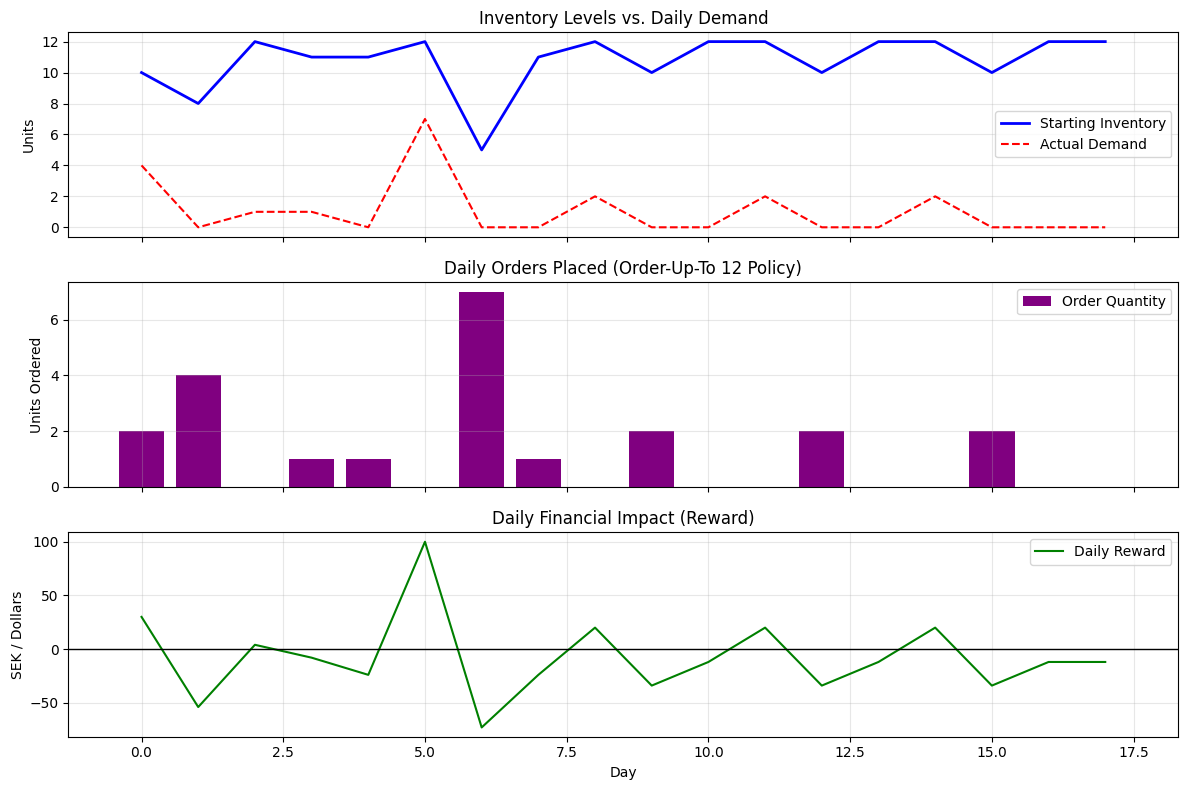

In [50]:
import numpy as np
import pandas as pd
from typing import Optional, Tuple, Dict, Any

class InventoryEnv:
    def __init__(
        self,
        demand_array: np.ndarray,  # NEW: We pass your actual demand array here
        max_inventory: int = 20,
        max_order: int = 6,
        holding_cost: float = 1.0,
        stockout_cost: float = 5.0,
        fixed_order_cost: float = 2.0,
        unit_purchase_cost: float = 10.0,
        unit_selling_price: float = 15.0,
        seed: Optional[int] = None,
    ):
        """
        Inventory Control Environment using pre-generated historical demand data.
        """
        # Store the provided demand array and ensure it's a numpy array of integers
        self.demand_array = np.array(demand_array, dtype=int)
        self.current_step = 0  # NEW: Tracks our current day/index in the demand array
        self.total_days = len(self.demand_array)

        # Cost & Revenue Parameters
        self.max_inventory = max_inventory
        self.max_order = max_order
        self.holding_cost = holding_cost
        self.stockout_cost = stockout_cost
        self.fixed_order_cost = fixed_order_cost
        self.unit_purchase_cost = unit_purchase_cost
        self.unit_selling_price = unit_selling_price

        # State tracking
        self.inventory = None

        # For render/debug tracking
        self.last_action = None
        self.last_demand = None
        self.last_units_sold = None
        self.last_unmet_demand = None
        self.last_reward = None

    def reset(self, inventory_init: Optional[int] = None) -> int:
        """
        Reset environment at the beginning of an episode.
        Returns the initial state (inventory).
        """
        # Reset our position in the demand array back to day 0
        self.current_step = 0

        # Initialize inventory
        if inventory_init is None:
            self.inventory = self.max_inventory // 2
        else:
            self.inventory = int(inventory_init)

        # Ensure starting inventory doesn't violate capacity bounds
        self.inventory = int(np.clip(self.inventory, 0, self.max_inventory))

        # Clear debug variables
        self.last_action = None
        self.last_demand = None
        self.last_units_sold = None
        self.last_unmet_demand = None
        self.last_reward = None

        return self.inventory

    def step(self, action: int) -> Tuple[int, float, bool, Dict[str, Any]]:
        """
        Take an action (order quantity) and simulate one day using the exact
        demand from our pre-loaded demand_array.
        """
        # 1. Clip action to ensure we don't order more than max_order
        order_qty = int(np.clip(action, 0, self.max_order))

        # 2. Arrivals (immediate delivery assumption)
        arrivals = order_qty

        # 3. Update inventory with arrivals, respecting max warehouse capacity
        self.inventory = min(self.max_inventory, self.inventory + arrivals)

        # 4. Fetch the exact demand for today from your array
        if self.current_step < self.total_days:
            demand = self.demand_array[self.current_step]
        else:
            demand = 0

        # 5. Compute sales, unmet demand, and end-of-day inventory
        units_sold = min(self.inventory, demand)
        unmet_demand = demand - units_sold
        self.inventory = self.inventory - units_sold

        # 6. Compute Financials / Reward
        revenue = self.unit_selling_price * units_sold

        if order_qty > 0:
            order_cost = self.fixed_order_cost + (self.unit_purchase_cost * order_qty)
        else:
            order_cost = 0.0

        holding_cost = self.holding_cost * self.inventory
        stockout_cost = self.stockout_cost * unmet_demand

        # Daily Reward Calculation
        reward = revenue - order_cost - holding_cost - stockout_cost

        # 7. Update trackers
        self.last_action = order_qty
        self.last_demand = demand
        self.last_units_sold = units_sold
        self.last_unmet_demand = unmet_demand
        self.last_reward = reward

        # Next state is the current end-of-day inventory
        next_state = self.inventory
        
        # Increment our day counter
        self.current_step += 1
        
        # The episode is finished when we run out of data in the array
        done = self.current_step >= self.total_days

        info = {
            "day": self.current_step,
            "order_qty": order_qty,
            "arrivals": arrivals,
            "inventory_end": self.inventory,
            "demand": demand,
            "units_sold": units_sold,
            "unmet_demand": unmet_demand,
            "reward": reward,
        }

        return next_state, reward, done, info

    def render(self) -> None:
        """
        Print a detailed snapshot of the current environment status.
        """
        print("=== ENVIRONMENT STATUS ===")
        print(f"Day               : {self.current_step} / {self.total_days}")
        print(f"Inventory         : {self.inventory}")
        if self.last_action is not None:
            print(f"Last action       : {self.last_action}")
        if self.last_demand is not None:
            print(f"Last demand       : {self.last_demand}")
        if self.last_units_sold is not None:
            print(f"Units sold        : {self.last_units_sold}")
        if self.last_unmet_demand is not None:
            print(f"Unmet demand      : {self.last_unmet_demand}")
        if self.last_reward is not None:
            print(f"Last reward       : {self.last_reward:.2f}")
        print("==========================\n")




# 1. Define the policy function OUTSIDE the class
def order_up_to_policy(state, S):    
    """    
    Base-stock policy: order enough to reach level S (capped by max_order inside env).    
    """
    order_qty = max(0, S - state)
    return order_qty

# 2. Load data from csv demamd serires
df = pd.read_csv('../data/demand/demand_series.csv')
demand = df['failure'].values

# 3. Initialize your new environment
env = InventoryEnv(demand_array=demand)

import matplotlib.pyplot as plt

# ---------------------------------------------------------
# TRACKING & EXECUTION LOGIC
# ---------------------------------------------------------

# Reset the environment to start a fresh simulation from Day 0
state = env.reset()
total_reward = 0.0
done = False

# We use standard Python lists `[]` to store our daily data.
# A list is a mutable (changeable) sequence of elements.
history_inventory = []
history_demand = []
history_orders = []
history_rewards = []

while not done:
    # Get the action (order quantity) from our policy.
    action = order_up_to_policy(state, S=12)
    
    # env.step() advances the simulation by one day. 
    # It returns a "tuple" (an unchangeable list) of four variables which we unpack here:
    # next_state: the inventory at the end of the day
    # reward: the profit/loss for the day
    # done: a boolean (True/False) telling us if we ran out of data
    # info: a dictionary (key-value pairs) containing detailed stats
    next_state, reward, done, info = env.step(action)
    
    # .append() is a built-in Python list method. 
    # It takes whatever value you put inside the parentheses and adds it to the very end of the list.
    history_inventory.append(state)                 # Track morning inventory
    history_demand.append(info["demand"])           # Track exact demand that happened
    history_orders.append(action)                   # Track how much we ordered
    history_rewards.append(reward)                  # Track daily profit/loss
    
    # += is the "addition assignment" operator. 
    # It is shorthand for: total_reward = total_reward + reward
    total_reward += reward
    
    # Update our state for tomorrow
    state = next_state

print(f"Total reward using actual demand data: {total_reward}")

# ---------------------------------------------------------
# VISUALIZATION LOGIC (MATPLOTLIB)
# ---------------------------------------------------------

# plt.subplots() creates two things:
# 1. fig: The overall figure (the window/canvas). We set its size to 12 inches wide, 8 inches tall.
# 2. axs: An array of "Axes" (individual plots). We asked for 3 rows and 1 column.
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# len() is a built-in Python function that returns the number of items in an object.
# range() creates a sequence of numbers from 0 up to (but not including) the number provided.
# Together, list(range(10)) creates [0, 1, 2, ..., 9] to represent our days on the X-axis.
days = list(range(len(history_inventory)))

# --- Plot 1: Inventory vs Demand ---
# .plot() draws a line chart. We pass the X values (days) and Y values (inventory/demand).
# label="" gives it a name for the legend, color="" sets the line color, alpha="" makes it slightly transparent.
axs[0].plot(days, history_inventory, label="Starting Inventory", color="blue", linewidth=2)
axs[0].plot(days, history_demand, label="Actual Demand", color="red", linestyle="--")
axs[0].set_title("Inventory Levels vs. Daily Demand") # Sets the title of the top chart
axs[0].set_ylabel("Units")                            # Labels the Y-axis
axs[0].legend()                                       # Displays the legend map
axs[0].grid(True, alpha=0.3)                          # Adds a faint grid to the background

# --- Plot 2: Ordering Behavior ---
# .bar() creates a bar chart instead of a line chart. Great for showing distinct daily quantities.
axs[1].bar(days, history_orders, color="purple", label="Order Quantity")
axs[1].set_title("Daily Orders Placed (Order-Up-To 12 Policy)")
axs[1].set_ylabel("Units Ordered")
axs[1].legend()
axs[1].grid(True, alpha=0.3)

# --- Plot 3: Daily Reward (Profit/Loss) ---
axs[2].plot(days, history_rewards, label="Daily Reward", color="green")
# .axhline() draws a horizontal line across the entire plot. 
# We put it at y=0 so you can easily see which days made money and which lost money.
axs[2].axhline(0, color="black", linestyle="-", linewidth=1)
axs[2].set_title("Daily Financial Impact (Reward)")
axs[2].set_xlabel("Day")
axs[2].set_ylabel("SEK / Dollars")
axs[2].legend()
axs[2].grid(True, alpha=0.3)

# .tight_layout() automatically adjusts the spacing between subplots so titles and labels don't overlap.
plt.tight_layout()

# .show() tells Matplotlib to actually render the graphic to your screen.
plt.show()

In [51]:
import numpy as np

# ---------------------------------------------------------
# 1. EMPIRICAL PROBABILITY DISTRIBUTION
# ---------------------------------------------------------

# np.bincount() is a built-in NumPy function that counts how many times each integer 
# appears in an array. 
# For example, if demand is [0, 0, 1, 4, 0], bincount returns [3, 1, 0, 0, 1].
# This tells us 0 happened three times, 1 happened once, and 4 happened once.
demand_counts = np.bincount(demand.astype(int))

# len() gets the total number of items in your array (the total number of simulated days)
total_days = len(demand)

def empirical_pmf(d, counts, total):
    """
    Probability Mass Function (PMF).
    Calculates the exact probability of a specific demand 'd' happening,
    based strictly on how often it appeared in your historical data.
    """
    # If the algorithm asks for the probability of a demand higher than 
    # anything we have ever seen in the array, the probability is 0.
    if d >= len(counts):
        return 0.0
    
    # Probability = (Number of times 'd' happened) / (Total number of days)
    return counts[d] / total

# ---------------------------------------------------------
# 2. SETTING UP THE MATRICES
# ---------------------------------------------------------

# We need the same parameters from your environment
max_inventory = env.max_inventory
max_order = env.max_order

# np.arange(X) creates an array of numbers from 0 up to X-1.
# If max_inventory is 20, this creates [0, 1, 2... 20]. These are our "States".
states = np.arange(max_inventory + 1)  
actions = np.arange(max_order + 1)     

num_states = len(states)
num_actions = len(actions)

# np.zeros(shape) creates an array filled completely with 0.0s.
# 'P' is our Transition Matrix. It is a 3D cube measuring [States x Actions x Next States].
# It holds the probability of moving from one state to another, given a specific action.
P = np.zeros((num_states, num_actions, num_states))

# 'R' is our Reward Matrix. It is a 2D grid measuring [States x Actions].
# It holds the expected profit/loss for taking a specific action in a specific state.
R = np.zeros((num_states, num_actions))

# The absolute maximum demand we mathematically care about in this simulation.
D_max = max_inventory + max_order

# ---------------------------------------------------------
# 3. FILLING THE MATRICES (THE CORE ENGINE)
# ---------------------------------------------------------

# We use nested loops to iterate through EVERY possible combination of State and Action.
for s in states:
    for a in actions:
        
        s_idx = s
        a_idx = a
        
        # min() returns the smallest of the items passed to it.
        # This calculates our inventory right after the delivery truck arrives, 
        # capped by our warehouse's maximum capacity.
        inv_pre = min(max_inventory, s + a)
        
        # Now we look at every possible demand that *could* happen today
        for d in range(D_max + 1):
            
            # Get the exact probability of this demand happening from your data
            p_d = empirical_pmf(d, demand_counts, total_days)
            
            # If the probability is 0, skip the math to save processing power
            if p_d == 0:
                continue
                
            # Calculate what happens to our stock
            units_sold = min(inv_pre, d)
            unmet_demand = d - units_sold
            s_next = inv_pre - units_sold  # End of day inventory (our next state)
            s_next_idx = s_next 
            
            # Calculate the finances for this specific scenario
            revenue = env.unit_selling_price * units_sold
            
            if a > 0:
                order_cost = env.fixed_order_cost + env.unit_purchase_cost * a
            else:
                order_cost = 0.0
                
            holding_cost = env.holding_cost * s_next
            stockout_cost = env.stockout_cost * unmet_demand
            
            r = revenue - order_cost - holding_cost - stockout_cost
            
            # Accumulate the probabilities and expected rewards into our matrices.
            # += adds the value on the right to the existing variable.
            P[s_idx, a_idx, s_next_idx] += p_d
            R[s_idx, a_idx] += p_d * r

# Optional sanity check: The sum of probabilities for moving to any next state should equal 1.0.
# .sum(axis=2) adds up all the probabilities across the 3rd dimension (Next States).
row_sums = P.sum(axis=2)
print("Matrix building complete!")
print(f"Sample row sum (should be 1.0): {row_sums[0, 0]}")

Matrix building complete!
Sample row sum (should be 1.0): 1.0


Value Iteration Complete!

Optimal Policy π*(s): (How much to order at each inventory level)
If you have  0 units -> Order 4 units
If you have  1 units -> Order 3 units
If you have  2 units -> Order 0 units
If you have  3 units -> Order 0 units
If you have  4 units -> Order 0 units
If you have  5 units -> Order 0 units
If you have  6 units -> Order 0 units
If you have  7 units -> Order 0 units
If you have  8 units -> Order 0 units
If you have  9 units -> Order 0 units
If you have 10 units -> Order 0 units
If you have 11 units -> Order 0 units
If you have 12 units -> Order 0 units
If you have 13 units -> Order 0 units
If you have 14 units -> Order 0 units
If you have 15 units -> Order 0 units
If you have 16 units -> Order 0 units
If you have 17 units -> Order 0 units
If you have 18 units -> Order 0 units
If you have 19 units -> Order 0 units
If you have 20 units -> Order 0 units


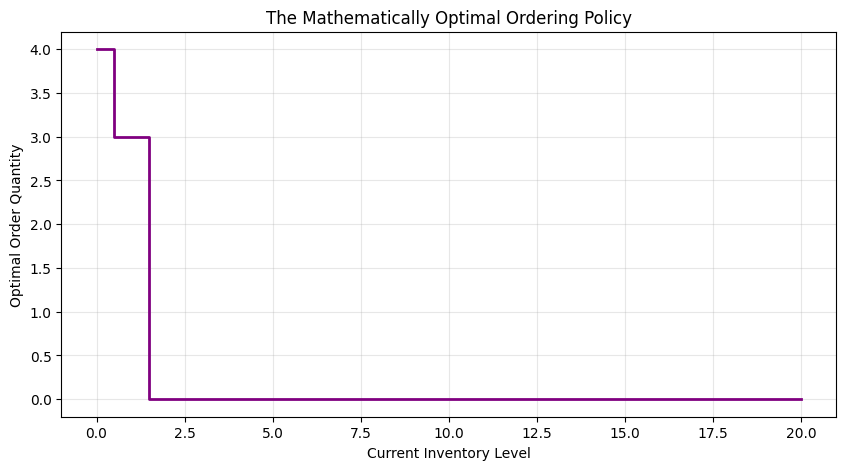

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. THE VALUE ITERATION ALGORITHM
# ---------------------------------------------------------

def value_iteration(P, R, gamma=0.99, theta=1e-6):
    """
    Finds the optimal expected long-term value for every state, 
    and the optimal ordering policy to achieve it.
    
    Parameters:
    P: Transition matrix [States x Actions x Next States]
    R: Reward matrix [States x Actions]
    gamma: Discount factor (0.99 means we care about tomorrow almost as much as today)
    theta: The stopping threshold (when the values stop changing by more than this tiny amount, we are done)
    """
    # .shape gets the dimensions of a NumPy array. 
    # Since P is a 3D matrix, it returns (number of states, number of actions, number of next states)
    num_states, num_actions, _ = P.shape

    # Initialize our Value array with zeros for every state.
    V = np.zeros(num_states)

    # This is a 'while True' loop. It will run forever until it hits the 'break' command inside.
    while True:
        delta = 0.0
        
        # np.zeros_like(V) creates a new array of zeros exactly the same size/shape as V.
        V_new = np.zeros_like(V)

        for s in range(num_states):
            Q_values = []
            for a in range(num_actions):
                # THE BELLMAN EQUATION:
                # Expected Value = Immediate Reward + (Discount Factor * Expected Future Value)
                # np.sum() adds up all the values inside the array.
                # P[s, a, :] extracts all the probabilities of moving to any next state.
                q = R[s, a] + gamma * np.sum(P[s, a, :] * V)
                
                # .append() adds this calculated 'q' value to our list.
                Q_values.append(q)
            
            # max() finds the highest number in a list.
            # We assume the agent is smart and will always pick the action with the highest expected value.
            V_new[s] = max(Q_values)
            
            # abs() gets the absolute value (removes negative signs).
            # This checks how much our calculated value changed in this loop compared to the last loop.
            delta = max(delta, abs(V_new[s] - V[s]))

        # Overwrite the old values with our newly calculated ones
        V = V_new

        # If the biggest change was smaller than our tiny threshold (theta), we have converged!
        if delta < theta:
            break

    # ---------------------------------------------------------
    # 2. EXTRACTING THE OPTIMAL POLICY
    # ---------------------------------------------------------
    
    # Create an array of integers (dtype=int) to hold our best action for each state
    policy = np.zeros(num_states, dtype=int)

    for s in range(num_states):
        best_q = -1e18 # Start with a massively negative number
        best_a = 0     # Default action
        
        for a in range(num_actions):
            # Recalculate the expected value one last time using our final optimized 'V' array
            q = R[s, a] + gamma * np.sum(P[s, a, :] * V)
            
            if q > best_q:
                best_q = q
                best_a = a
                
        # Save the absolute best action for this specific inventory level
        policy[s] = best_a

    return V, policy

# Run the algorithm on our matrices!
V_star, pi_star = value_iteration(P, R, gamma=0.99, theta=1e-6)

print("Value Iteration Complete!")
print("\nOptimal Policy π*(s): (How much to order at each inventory level)")
for s in range(num_states):
    print(f"If you have {s:2d} units -> Order {pi_star[s]} units")

# Let's visualize this optimal policy!
plt.figure(figsize=(10, 5))
# plt.step() creates a stepped line graph, perfect for showing discrete policy changes.
plt.step(np.arange(num_states), pi_star, where="mid", color="purple", linewidth=2)
plt.xlabel("Current Inventory Level")
plt.ylabel("Optimal Order Quantity")
plt.title("The Mathematically Optimal Ordering Policy")
plt.grid(True, alpha=0.3)
plt.show()